
🔹 Sau split lần 1:
   TRAIN: (807, 13) Counter({0: 800, 1: 7})
   VAL  : (4060, 13) Counter({0: 4000, 1: 60})
   TEST : (6090, 13) Counter({0: 6000, 1: 90})

🔹 SAU khi chỉnh TRAIN/TEST (nếu có):
   TRAIN: (807, 13) Counter({0: 800, 1: 7})
   VAL  : (4060, 13) Counter({0: 4000, 1: 60})
   TEST : (6090, 13) Counter({0: 6000, 1: 90})

🔧 Sau preprocess:
   TRAIN: (807, 90)
   VAL  : (4060, 90)
   TEST : (6090, 90)

🟢 Số NORMAL dùng train OCSVM: 800
🔴 Số ANOMALY có trong TRAIN (không dùng cho OCSVM): 7

🔍 Tuning (nu, percentile q) theo **F1-binary** trên VALIDATION:
  nu=0.200, q=0.8000 → F1_val_binary=0.1078
  nu=0.200, q=0.8200 → F1_val_binary=0.1188
  nu=0.200, q=0.8400 → F1_val_binary=0.1324
  nu=0.200, q=0.8600 → F1_val_binary=0.1494
  nu=0.200, q=0.8800 → F1_val_binary=0.1715
  nu=0.200, q=0.9000 → F1_val_binary=0.0815
  nu=0.200, q=0.9200 → F1_val_binary=0.0987
  nu=0.200, q=0.9400 → F1_val_binary=0.1250
  nu=0.200, q=0.9600 → F1_val_binary=0.1525
  nu=0.200, q=0.9800 → F1_val_binar

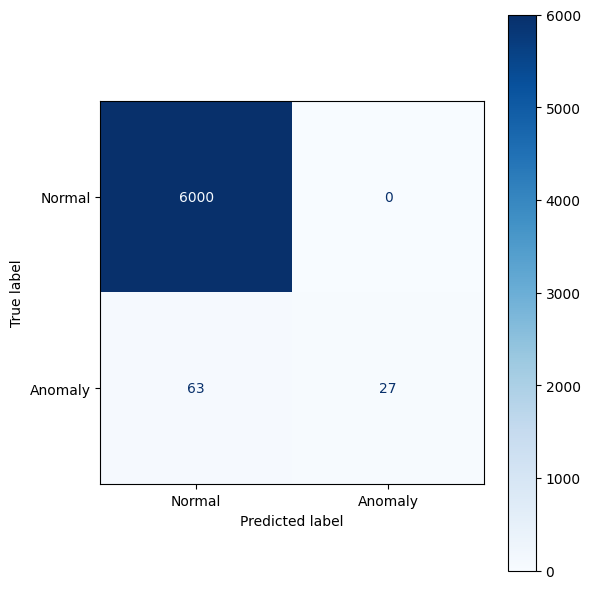

In [9]:
# ============================================
# ONE-CLASS SVM cho dữ liệu IEC 61850 (Data.csv)
# - TRAIN/VAL/TEST đọc từ: label_pool / val_labeled_40 / test_labeled_60
# - OCSVM: train CHỈ TRÊN 800 NORMAL từ TRAIN
# - Tuning (nu, percentile q) theo **F1-binary** trên VALIDATION  <-- CHỈ ĐỔI CHỖ NÀY
# - Đánh giá trên TEST: **AUROC + F1-binary + MCC**              <-- VÀ IN 3 CHỈ SỐ
# ============================================

from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, matthews_corrcoef
)
import random
from collections import Counter

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import OneClassSVM

import matplotlib.pyplot as plt
import time

t0 = time.perf_counter()
# ------------------------------------------------
# 0. FIX SEED (GIỮ NGUYÊN)
# ------------------------------------------------
np.random.seed(42)
random.seed(0)

# ------------------------------------------------
# 1. ĐỌC DATA TỪ CÁC CSV ĐÃ CHIA SẴN (GIỮ NGUYÊN)
# ------------------------------------------------
train_df = pd.read_csv("label_pool.csv")
val_df   = pd.read_csv("val_labeled_40.csv")
test_df  = pd.read_csv("test_labeled_60.csv")

FEATURES = [c for c in train_df.columns if c != "Label"]
X_train, y_train = train_df[FEATURES], train_df["Label"]
X_val,   y_val   = val_df[FEATURES],   val_df["Label"]
X_test,  y_test  = test_df[FEATURES],  test_df["Label"]

print("\n🔹 Sau split lần 1:")
print("   TRAIN:", X_train.shape, Counter(y_train))
print("   VAL  :", X_val.shape,   Counter(y_val))
print("   TEST :", X_test.shape,  Counter(y_test))

# ------------------------------------------------
# 4. (Giữ nguyên TRAIN/VAL/TEST như đã đọc từ CSV) (GIỮ NGUYÊN)
# ------------------------------------------------
rng = np.random.default_rng(42)

Xtr0 = X_train.copy()
ytr0 = y_train.copy()

idx_a_tr = ytr0.index[ytr0 == 1]
idx_n_tr = ytr0.index[ytr0 == 0]

n_keep = min(4, len(idx_a_tr))
keep_a = pd.Index(rng.choice(idx_a_tr, size=n_keep, replace=False))
drop_a = idx_a_tr.difference(keep_a)

# (GIỮ NGUYÊN: không move anomaly dư sang test)
# Nếu bạn muốn move thì tự UNCOMMENT đúng như bản bạn gửi.

# Reset index
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print("\n🔹 SAU khi chỉnh TRAIN/TEST (nếu có):")
print("   TRAIN:", X_train.shape, Counter(y_train))
print("   VAL  :", X_val.shape,   Counter(y_val))
print("   TEST :", X_test.shape,  Counter(y_test))

# ------------------------------------------------
# 5. TIỀN XỬ LÝ (ColumnTransformer) (GIỮ NGUYÊN)
# ------------------------------------------------
num_features = [
    "Length", "heartbeat", "I-high VT", "I-high VT- Tran",
    "I-low VT- Tran", "I-amongst-feeders", "sqNum"
]

Circuit_breaker_Open_Close_Status_level = [
    np.sort(X_train["Circuit breaker Open/Close Status"].unique()).tolist()
]

nom_features = ["stNum", "Source", "dif_stNum", "dif_sqNum", "goID"]

num_transformer = Pipeline(steps=[
    ("num_scaler", StandardScaler())
])

ord_transformer = Pipeline(steps=[
    ("encoder", OrdinalEncoder(
        categories=Circuit_breaker_Open_Close_Status_level,
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

nom_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num_feature", num_transformer, num_features),
        ("ord_feature", ord_transformer, ["Circuit breaker Open/Close Status"]),
        ("nom_feature", nom_transformer, nom_features),
    ],
    remainder="drop"
)

reg = Pipeline(steps=[("preprocessor", preprocessor)])
reg.fit(X_train)

X_train_proc = reg.transform(X_train)
X_val_proc   = reg.transform(X_val)
X_test_proc  = reg.transform(X_test)

print("\n🔧 Sau preprocess:")
print("   TRAIN:", X_train_proc.shape)
print("   VAL  :", X_val_proc.shape)
print("   TEST :", X_test_proc.shape)

# ------------------------------------------------
# 6. ONE-CLASS SVM: TRAIN CHỈ TRÊN 800 NORMAL (GIỮ NGUYÊN)
# ------------------------------------------------
idx_n_train = np.flatnonzero(y_train.values == 0)

n_use = min(800, len(idx_n_train))
X_train_normal = X_train_proc[idx_n_train[:n_use]]

print("\n🟢 Số NORMAL dùng train OCSVM:", X_train_normal.shape[0])
print("🔴 Số ANOMALY có trong TRAIN (không dùng cho OCSVM):",
      np.sum(y_train.values == 1))

# ------------------------------------------------
# 7. TUNING (nu, percentile q) THEO **F1-BINARY** TRÊN VALIDATION
#    (KHÔNG ĐỔI candidate_nu, q_grid; chỉ đổi metric chọn best)
# ------------------------------------------------
candidate_nu = [0.2]

coarse = np.linspace(0.80, 0.98, 10, endpoint=True)
fine   = np.linspace(0.98, 0.999, 15, endpoint=True)
q_grid = np.unique(np.concatenate([coarse, fine]))

best_f1_binary = -1.0
best_nu = None
best_q = None
best_tau = None
best_model = None

y_val_np = y_val.values.astype(int)

print("\n🔍 Tuning (nu, percentile q) theo **F1-binary** trên VALIDATION:")

for nu in candidate_nu:
    # 1) Train OCSVM với nu (GIỮ NGUYÊN)
    oc = OneClassSVM(kernel="linear", gamma="scale", nu=nu)
    oc.fit(X_train_normal)

    # 2) Score anomaly trên VALIDATION (GIỮ NGUYÊN)
    scores_val_raw = oc.decision_function(X_val_proc)  # lớn hơn = normal
    scores_val = -scores_val_raw                        # lớn hơn = anomaly

    for q in q_grid:
        tau = np.percentile(scores_val, q * 100.0)

        # anomaly = score >= tau
        y_pred_val = (scores_val >= tau).astype(int)

        # >>> F1-BINARY (pos_label=1) trên validation <<<
        f1_binary = f1_score(
            y_val_np,
            y_pred_val,
            average="binary",
            pos_label=1,
            zero_division=0
        )

        # (Bạn có thể comment dòng print này nếu quá nhiều log)
        print(f"  nu={nu:.3f}, q={q:.4f} → F1_val_binary={f1_binary:.4f}")

        if f1_binary > best_f1_binary:
            best_f1_binary = f1_binary
            best_nu = nu
            best_q = q
            best_tau = tau
            best_model = oc
# ---- TRAIN ----

print("\n✅ Best trên VALIDATION (theo F1-binary):")
print(f"   nu*           = {best_nu}")
print(f"   q*            = {best_q:.4f}")
print(f"   tau*          = {best_tau:.6f}")
print(f"   F1_val_binary = {best_f1_binary:.4f}")
t1 = time.perf_counter()
# ------------------------------------------------
# 8. ĐÁNH GIÁ TRÊN TEST (DÙNG (nu*, tau*) TỪ VAL)
#    In ra: AUROC + F1-binary + MCC
# ------------------------------------------------
oc_best = best_model

scores_test_raw = oc_best.decision_function(X_test_proc)  # lớn hơn = normal
scores_test = -scores_test_raw                              # lớn hơn = anomaly

y_test_np = y_test.values.astype(int)

# 1) AUROC (score liên tục, không phụ thuộc threshold) (GIỮ NGUYÊN)
auroc_test = roc_auc_score(y_test_np, scores_test) if len(np.unique(y_test_np)) > 1 else float("nan")

# 2) Phân loại bằng tau*
y_pred_test = (scores_test >= best_tau).astype(int)

# 3) F1-binary (pos_label=1)
f1_binary_test = f1_score(
    y_test_np,
    y_pred_test,
    average="binary",
    pos_label=1,
    zero_division=0
)

# 4) MCC
mcc_test = matthews_corrcoef(y_test_np, y_pred_test) if len(np.unique(y_test_np)) > 1 else 0.0
# ---- TEST ----
def format_time(seconds):
    minutes = int(seconds // 60)
    secs = seconds % 60
    return f"{minutes:d} min {secs:05.2f} s"
t2= time.perf_counter()

print(f"Training time   : {format_time(t1 - t0)}")
print(f"Testing time    : {format_time(t2 - t1)}")


print("\n📈 KẾT QUẢ TRÊN TEST (OCSVM + threshold percentile, chọn theo VAL F1-binary):")
print("-----------------------------------------------------")
print(f"nu*              = {best_nu}")
print(f"q*               = {best_q:.4f}")
print(f"tau*             = {best_tau:.6f}")
print(f"AUROC_test       = {(auroc_test * 100 if auroc_test==auroc_test else float('nan')):.3f}%")
print(f"F1_test (binary) = {f1_binary_test:.4f}")
print(f"MCC_test         = {mcc_test:.4f}")

# (Optional) confusion matrix để bạn kiểm tra (không ảnh hưởng hyperparameter)
cm = confusion_matrix(y_test_np, y_pred_test)
print("\n🧩 Confusion matrix trên TEST (rows=true, cols=pred):")
print(cm)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])
disp.plot(cmap="Blues", colorbar=True, ax=ax)
plt.title("")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()

plt.savefig("confusion_matrix_OC-SVM.png", dpi=300, bbox_inches="tight")
plt.show()


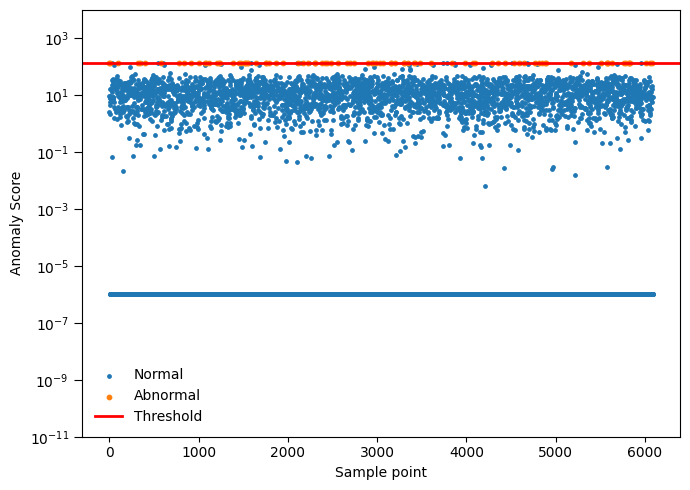

Saved: MonitoringChart_OC-SVM.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext

def plot_monitoring_chart_colored_orange(scores, labels, thr,
                                         title="",
                                         out_png="MonitoringChart_colored.png",
                                         point_size_norm=6,
                                         point_size_anom=10):
    scores = np.asarray(scores).reshape(-1)
    labels = np.asarray(labels).reshape(-1).astype(int)
    x = np.arange(len(scores))

    # tránh log(0)
    eps = 1e-6
    scores_plot = np.maximum(scores, eps)
    thr_plot = max(thr, eps)

    mask_norm = (labels == 0)
    mask_anom = (labels == 1)

    plt.figure(figsize=(7, 5))

    # Normal: xanh (mặc định)
    plt.scatter(x[mask_norm], scores_plot[mask_norm], s=point_size_norm, label="Normal")

    # Abnormal: CAM
    plt.scatter(x[mask_anom], scores_plot[mask_anom], s=point_size_anom, color="tab:orange", label="Abnormal")

    # Threshold: đỏ
    plt.axhline(thr_plot, linewidth=2, color="red", label="Threshold")

    # Trục Y giống style bạn đang dùng
    plt.yscale("log")
    plt.ylim(1e-11, 1e4)

    ax = plt.gca()
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_major_formatter(LogFormatterMathtext())
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
    ax.tick_params(axis="y", which="major", length=6)
    ax.tick_params(axis="y", which="minor", length=3)

    plt.xlabel("Sample point")
    plt.ylabel("Anomaly Score")
    plt.title(title)
    plt.legend(frameon=False)
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {out_png}")

plot_monitoring_chart_colored_orange(
    scores=scores_test,
    labels=y_test_np,   # 0=Normal, 1=Abnormal
    thr=best_tau,
    title="",
    out_png="MonitoringChart_OC-SVM.png"
)



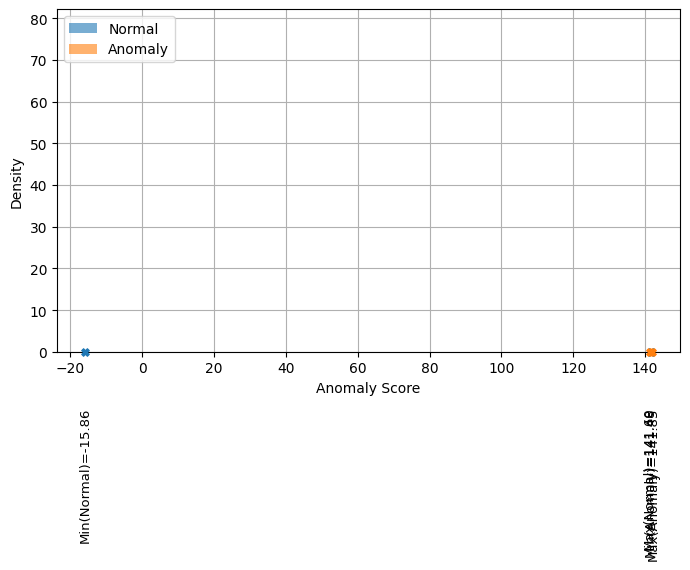

Saved: OCSVM_anomaly_score_histogram_labeled_minmax.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# INPUT (lấy từ OCSVM của bạn)
# ==============================
# scores_test  : anomaly score (continuous)
# y_test_np    : nhãn 0=Normal, 1=Anomaly

scores_normal  = scores_test[y_test_np == 0]
scores_anomaly = scores_test[y_test_np == 1]

# ==============================
# MIN / MAX
# ==============================
n_min, n_max = float(np.min(scores_normal)), float(np.max(scores_normal))
a_min, a_max = float(np.min(scores_anomaly)), float(np.max(scores_anomaly))

# ==============================
# PLOT
# ==============================
plt.figure(figsize=(7, 6))

plt.hist(scores_normal, bins=40, density=True,
         alpha=0.6, label="Normal")

plt.hist(scores_anomaly, bins=40, density=True,
         alpha=0.6, label="Anomaly")

# ---- Dấu X cắt trục x ----
plt.scatter([n_min, n_max], [0, 0],
            s=30, marker="X",
            linewidths=0.8, zorder=10, clip_on=False)

plt.scatter([a_min, a_max], [0, 0],
            s=30, marker="X",
            linewidths=0.8, zorder=10, clip_on=False)

# ==============================
# TEXT POSITION
# ==============================
ymin, ymax = plt.gca().get_ylim()
y_text = ymin - 0.16 * (ymax - ymin)

# ==============================
# LABELS
# ==============================
plt.text(n_min, y_text, f"Min(Normal)={n_min:.2f}",
         ha="center", va="top", fontsize=9.5,
         rotation=90, clip_on=False)

plt.text(n_max-0.5, y_text, f"Max(Normal)={n_max:.2f}",
         ha="center", va="top", fontsize=9.5,
         rotation=90, clip_on=False)

plt.text(a_min, y_text, f"Min(Anomaly)={a_min:.2f}",
         ha="center", va="top", fontsize=9.5,
         rotation=90, clip_on=False)

plt.text(a_max+0.5, y_text, f"Max(Anomaly)={a_max:.2f}",
         ha="center", va="top", fontsize=9.5,
         rotation=90, clip_on=False)

# ==============================
# STYLE
# ==============================
plt.xlabel("Anomaly Score")
plt.ylabel("Density")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    "OCSVM_anomaly_score_histogram_labeled_minmax.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

print("Saved: OCSVM_anomaly_score_histogram_labeled_minmax.png")
